In [13]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree 

df = pd.read_csv('healthcare_dataset.csv')
df.head(15)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [14]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

In [15]:
df.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [16]:
for col in df.columns:
    new_col = col.capitalize()  # Capitalize the first letter
    df.rename(columns={col: new_col}, inplace=True)

    print(df)
df.info()

                    Name  Age  Gender Blood Type Medical Condition  \
0          Bobby JacksOn   30    Male         B-            Cancer   
1           LesLie TErRy   62    Male         A+           Obesity   
2            DaNnY sMitH   76  Female         A-           Obesity   
3           andrEw waTtS   28  Female         O+          Diabetes   
4          adrIENNE bEll   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
55495  eLIZABeTH jaCkSOn   42  Female         O+            Asthma   
55496         KYle pEREz   61  Female        AB-           Obesity   
55497       HEATher WaNG   38  Female         B+      Hypertension   
55498     JENniFER JOneS   43    Male         O-         Arthritis   
55499       jAMES GARCiA   53  Female         O+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            2024-01-31     Matthew Smith               Sons and Miller   
1        

In [17]:
clean_df= df.dropna(axis=1)
clean_df.head(15)

,Name,Age,Gender,Blood type,Medical condition,Date of admission,Doctor,Hospital,Insurance provider,Billing amount,Room number,Admission type,Discharge date,Medication,Test results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [18]:
# Standardize string formats to avoid duplicates like 'Male' and 'male'
df.columns = df.columns.str.strip()
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
 df[col] = df[col].str.strip().str.title()

C:\Users\ERIC\AppData\Local\Temp\ipykernel_9956\4031743229.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns


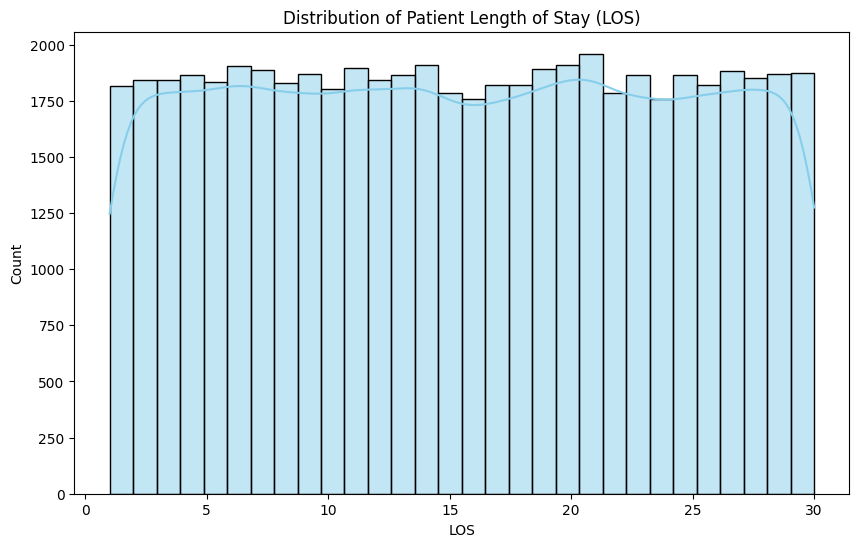

C:\Users\ERIC\AppData\Local\Temp\ipykernel_9956\1014064350.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Admission type', y='LOS', data=df, palette='Set2')


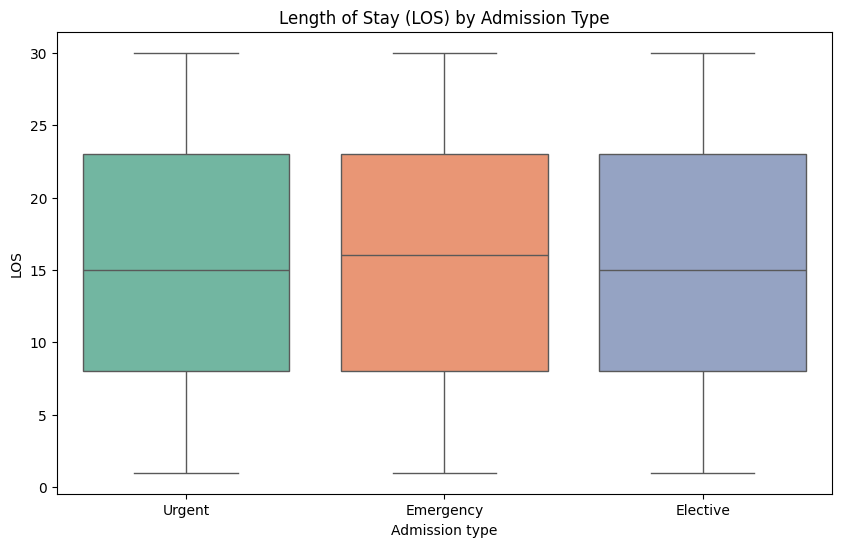

C:\Users\ERIC\AppData\Local\Temp\ipykernel_9956\1014064350.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LOS', y='Medical condition', data=avg_los_condition, palette='viridis')


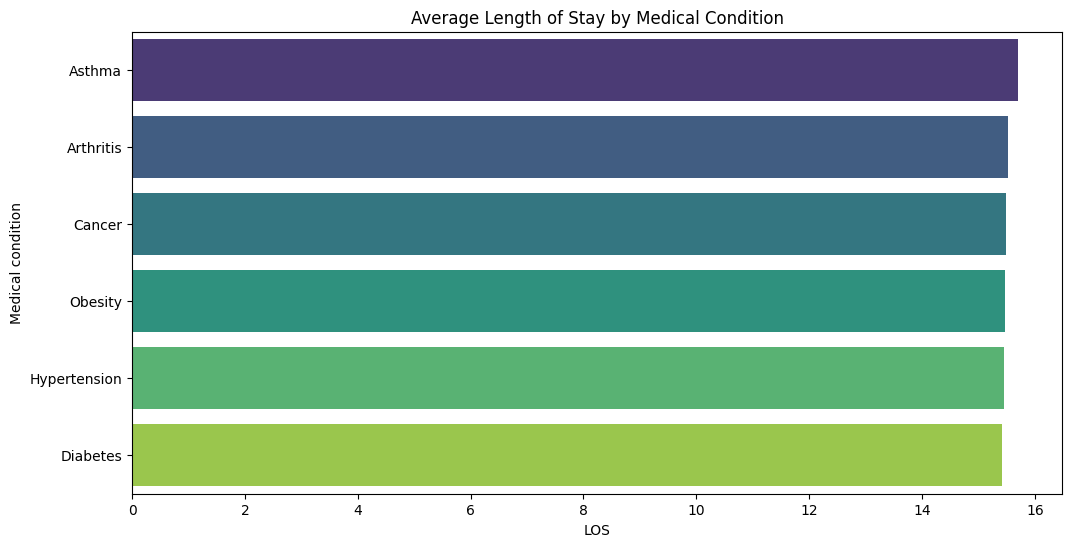

Visualizations saved: los_distribution.png, los_by_admission_type.png, avg_los_by_condition.png


In [19]:
# Convert dates and calculate Length of Stay (LOS)
df['Date of Admission'] = pd.to_datetime(df['Date of admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge date'])
df['LOS'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Visualization 1: Distribution of Length of Stay (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['LOS'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Patient Length of Stay (LOS)')
plt.show()
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('los_distribution.png')
plt.close()

# Visualization 2: LOS by Admission Type (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Admission type', y='LOS', data=df, palette='Set2')
plt.title('Length of Stay (LOS) by Admission Type')
plt.show()
plt.xlabel('Admission type')
plt.ylabel('Days')
plt.savefig('los_by_admission_type.png')
plt.close()

# Visualization 3: LOS by Medical Condition (Barplot)
plt.figure(figsize=(12, 6))
avg_los_condition = df.groupby('Medical condition')['LOS'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='LOS', y='Medical condition', data=avg_los_condition, palette='viridis')
plt.title('Average Length of Stay by Medical Condition')
plt.show()
plt.xlabel('Average Days')
plt.ylabel('Medical Condition')
plt.tight_layout()
plt.savefig('avg_los_by_condition.png')
plt.close()


print("Visualizations saved: los_distribution.png, los_by_admission_type.png, avg_los_by_condition.png")

In [20]:
# We use Label Encoding for Ordinal/Binary data and target variables
le = LabelEncoder()
    
 # Target Variable for Classification: Admission Type
df['Target_Acuity'] = le.fit_transform(df['Admission type'])
# Feature Encoding
df['Gender_Enc'] = le.fit_transform(df['Gender'])
df['Condition_Enc'] = le.fit_transform(df['Medical condition'])
df['Test_Results_Enc'] = le.fit_transform(df['Test results'])
df['Blood_Type_Enc'] = le.fit_transform(df['Blood type'])

In [21]:
# 4. Feature Selection
    # We drop identifiers like Name, Doctor, and Room Number which don't help prediction
features = ['Age', 'Gender_Enc', 'Condition_Enc', 'Test_Results_Enc', 'Blood_Type_Enc']
X = df[features]
    
    # Target 1: Acuity (Classification)
y_clf = df['Target_Acuity']
    
    # Target 2: Length of Stay (Regression)
y_reg = df['LOS']

    # 5. Splitting the Data (80/20 Rule)
X_train, X_test, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
    )

In [22]:
# 6. Scaling Numerical Features
# Age has a wide range, so we scale it for better model convergence
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
    
X_train_scaled[['Age']] = scaler.fit_transform(X_train[['Age']])
X_test_scaled[['Age']] = scaler.transform(X_test[['Age']])

print(X_train_scaled.head())
# Execute Preprocessing
print(f"Preprocessing Complete. Training set size: {X_train.shape[0]}")

            Age  Gender_Enc  Condition_Enc  Test_Results_Enc  Blood_Type_Enc
16112 -0.538222           0              2                 2               2
10053  0.380684           0              5                 1               0
42049  0.789086           1              4                 2               1
28079 -0.997675           1              1                 0               3
15448 -0.538222           1              4                 2               0
Preprocessing Complete. Training set size: 44400


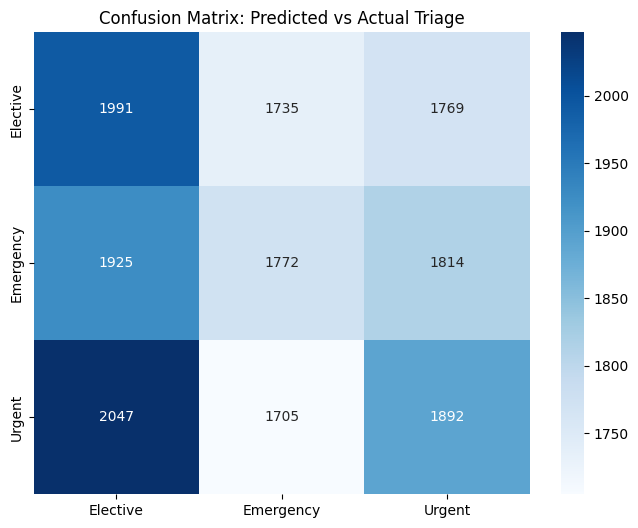

              precision    recall  f1-score      support
Elective       0.333892  0.362329  0.347530   5495.00000
Emergency      0.339985  0.321539  0.330505   5511.00000
Urgent         0.345571  0.335223  0.340318   5644.00000
accuracy       0.339640  0.339640  0.339640      0.33964
macro avg      0.339816  0.339697  0.339451  16650.00000
weighted avg   0.339868  0.339640  0.339450  16650.00000


In [27]:
#2. Encode categorical features and target
le_cond = LabelEncoder()
le_res = LabelEncoder()
le_target = LabelEncoder()

df['Condition_Enc'] = le_cond.fit_transform(df['Medical condition'])
df['Test_Results_Enc'] = le_res.fit_transform(df['Test results'])
df['Gender_Enc'] = le_target.fit_transform(df['Gender'])

# Features and Target
X = df[['Age', 'Gender_Enc', 'Condition_Enc', 'Test_Results_Enc']]
y = df['Admission type']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Train Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. Predictions
y_pred = clf.predict(X_test)

# 6. Generate Metrics
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# 7. Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Confusion Matrix: Predicted vs Actual Triage')
plt.show()
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.savefig('confusion_matrix.png')
plt.close()

print(report_df)